# Laboratorium 6: Aproksymacja wielomianami trygonometrycznymi 
Dla zadanej funkcji $f(x) = 10 + 0.5x^2 - 10\text{cos}(2x)$ określonej na przedziale $[-3\pi, 3\pi]$ wyznaczymy jej wartość w $n$ zadanych, dyskretnych punktach. Na podstawie tych punktów wyznaczymy przybliżenie tej funkcji za pomocą aproksymacji średniokwadratowej.

Jako bazę $\{\phi_i\}_{i \in \{0, 1, \dots, 2m + 1 \}}$ obierzemy
$$
\phi_0 = 1, \phi_1 = \text{sin}(x), \phi_2 = \text{cos}(x), \phi_3 = \text{sin}(2x), \phi_4 = \text{cos}(2x), \dots
$$

## Krok 1: Importy i definicja funkcji
Importujemy potrzebne biblioteki: `numpy` oraz `matplotlib.pyplot`. Definiujemy naszą funkcję $f$. Generujemy gęstą siatkę referencyjną o $N = 1000$ węzłach, w której będziemy testowali zgodność naszej przybliżonej funkcji.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Definicja badanej funkcji referencyjnej
def f(x):
    return 10 + 0.5 * x**2 - 10 * np.cos(2 * x)

# 2. Definicja przedziału [-3pi, 3pi]
a, b = -3 * np.pi, 3 * np.pi

# 3. Gęsta siatka kontrolna (do liczenia RMSE i rysowania gładkich wykresów)
x_dense = np.linspace(a, b, 1000)
y_true_dense = f(x_dense)

# Ustawienia globalne dla wykresów (opcjonalne, dla lepszej czytelności)
plt.rcParams['figure.dpi'] = 100

## Krok 2: Silnik aproksymacji
Z racji, że analizowane przez nas bazy $\{\phi_i\}_{i \in \{0, 1, \dots, 2m + 1 \}}$ nie są ortogonalne, stworzymy, tak jak na wykładzie, ogólny **układ normalny** stanowiący równanie macierzowe $G \cdot A = B$, który następnie rozwiążemy za pomocą `np.linalg.solve`.

Dla przypomnienia, szukamy takiego przybliżenia $\~{f}(x) = \sum\limits_{j=0}^{2m + 1} a_j \phi_j(x)$, aby zminimalizować błąd średniokwadratowy, czyli znaleźć współczynniki $a_j$ takie, że:
$$
min || f(x) - \~{f}(x) || = min \sum_{i = 0}^{n} w(x_i) \left[ f(x_i) - \sum_{j = 0}^{2m + 1} a_j \phi_j (x_i) \right]
$$
Ponadto, przyjmuję, że funkcja wagi $w$ jest tożsamościowo równa jeden (wszystkie pomiary mają taką samą wagę): $w \equiv 1$. Sumę kwadratów odchyłek (sumaryczny błąd) będę natomiast oznaczał za pomocą $H(x)$.

Aby znaleźć współczynniki $a_j$, tworzymy układ $m + 1$ równań:

$$
\frac{\partial H}{\partial a_k}(x) = 0 \iff \sum_{i = 0}^{n} \phi_k(x_i) \left[ f(x_i) - \sum_{j = 0}^{2m + 1} a_j \phi_j(x_i) \right] = 0, \quad k \in \{0, 1, \dots, m \}
$$

### Uwaga na temat `np.linalg.solve`:
Ta funkcja używa pod spodem **rozkładu LU z częściowym wyborem elementu podstawowego** (ang. *LU decomposition with partial pivoting*).

In [2]:
def solve_approximation(x_points, y_points, basis_functions):
    m = len(basis_functions)
    
    # Budujemy macierz G (macierz układu normalnego)
    G = np.zeros((m, m))
    B = np.zeros(m)
    
    # Wypełniamy macierz G i wektor B
    for i in range(m):
        for j in range(m):
            G[i, j] = np.sum(basis_functions[i](x_points) * basis_functions[j](x_points))
        B[i] = np.sum(y_points * basis_functions[i](x_points))
    
    # Rozwiązujemy układ równań
    coeffs = np.linalg.solve(G, B)
    return coeffs

## Krok 3: Definicja baz wektorowych
Tutaj definiujemy nasze bazy $\{\phi_i \}_{i \in \{0, 1, \dots, m \}}$. W zadaniu rozpatrujemy bazę trygonometryczną, musimy pamiętać o odpowiednim przeskalowaniu funkcji bazowych. Domyślnie mają one okres równy $2\pi$, natomiast w ogólnym przypadku, gdy rozważamy przedział $[a, b]$, musimy wziąć pod uwagę jego długość i tak przeskalować funkcje trygonometryczne, aby rozciągnąć/ścisnąć ten okres tak, aby wypełniał cały przedział.

In [3]:
# Baza trygonometryczna: 1, cos(kx), sin(kx)... 
def get_trig_basis(m):
    basis = [lambda x: np.ones_like(x)]
    L = b - a
    for k in range(1, m + 1):
        basis.append(lambda x, k=k: np.cos(2 * np.pi * k * x / L))
        basis.append(lambda x, k=k: np.sin(2 * np.pi * k * x / L))
    return basis

## Krok 4: Definicja funkcji ewaluacji i funkcji błędu
Funkcja ewaluacji dostaje na wejściu wartości $x$, bazę, oraz współczynniki stojące przy odpowiednich elementach bazy. Jako funkcję błędu przyjęto błąd średniokwadratowy (*MSE*, nie *RMSE*).

In [4]:
# Obliczanie wartości modelu dla podanych x
def evaluate_model(x_vals, coeffs, basis_functions):
    y_vals = np.zeros_like(x_vals, dtype=float)
    for c, func in zip(coeffs, basis_functions):
        y_vals += c * func(x_vals)
    return y_vals

# Błąd średniokwadratowy
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

### Eksperyment 1: Układ niedookreślony ($R < 1$)

W tym wariancie celowo doprowadzamy do sytuacji, w której układ równań normalnych staje się niedookreślony. 

**Parametry:**
* Stopień bazy: $m = 10$
* Liczba funkcji bazowych: $2m + 1 = 21$
* Liczba węzłów pomiarowych: $n = 15$
* Stosunek informacji do parametrów: $R = \frac{n}{2m+1} \approx 0.71$

**Cel i oczekiwania:**
Chcemy udowodnić bezwzględny wymóg matematyczny metody najmniejszych kwadratów. Ponieważ dostarczamy algorytmowi mniej punktów (równań) niż poszukiwanych współczynników modelu (niewiadomych), macierz układu $G$ staje się osobliwa. Oczekujemy, że algorytm albo rzuci błędem (`LinAlgError`), albo, z powodu niedoskonałości zmiennoprzecinkowych, wygeneruje niefizyczne, gigantyczne oscylacje między węzłami pomiarowymi.

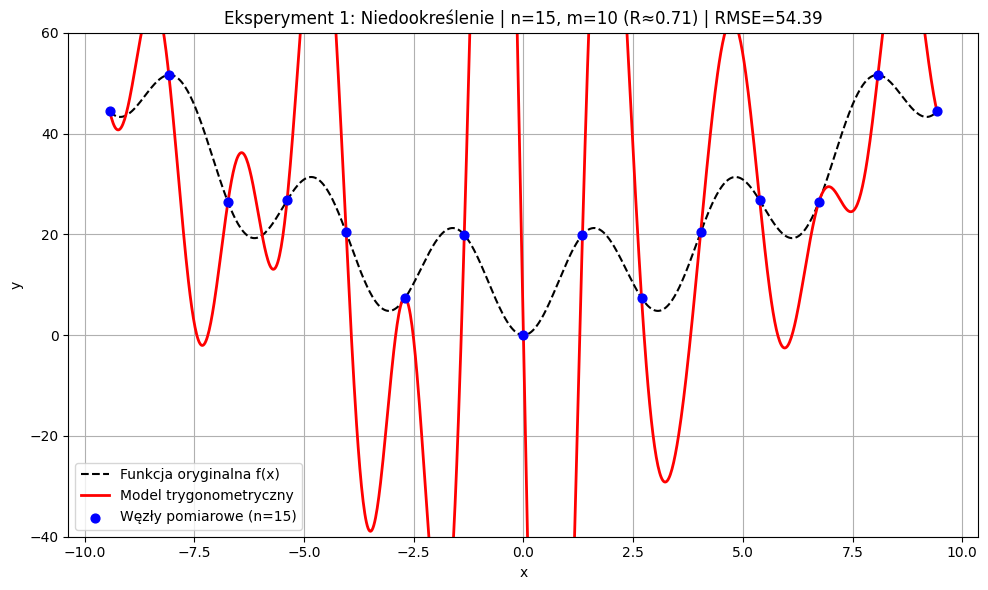

Zapisano wykres do: ./plots/trigonometric/exp1_n15_m10.png


In [7]:
# ==========================================
# EKSPERYMENT 1: Układ niedookreślony (R < 1)
# ==========================================

n1 = 15
m1 = 10
# Liczba funkcji bazowych = 2*10 + 1 = 21
# R = 15 / 21 ≈ 0.71

x_nodes1 = np.linspace(a, b, n1)
y_nodes1 = f(x_nodes1)
basis1 = get_trig_basis(m1)

plt.figure(figsize=(10, 6))
plt.plot(x_dense, y_true_dense, 'k--', label='Funkcja oryginalna f(x)')

try:
    coeffs1 = solve_approximation(x_nodes1, y_nodes1, basis1)
    y_approx1 = evaluate_model(x_dense, coeffs1, basis1)
    rmse1 = np.sqrt(calculate_mse(y_true_dense, y_approx1))
    
    plt.plot(x_dense, y_approx1, 'r-', linewidth=2, label='Model trygonometryczny')
    title1 = f'Eksperyment 1: Niedookreślenie | n={n1}, m={m1} (R≈0.71) | RMSE={rmse1:.2f}'
    
except np.linalg.LinAlgError:
    title1 = f'Eksperyment 1: Niedookreślenie | n={n1}, m={m1} (R≈0.71) | BŁĄD OSOBLIWOŚCI'
    print("Ostrzeżenie: Przechwycono LinAlgError - macierz idealnie osobliwa.")

plt.scatter(x_nodes1, y_nodes1, color='blue', s=40, zorder=5, label=f'Węzły pomiarowe (n={n1})')

plt.title(title1)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Ograniczamy oś Y, aby wykres był czytelny w przypadku gigantycznych "wystrzałów"
plt.ylim(-40, 60)

os.makedirs("./plots/trigonometric", exist_ok=True)
path1 = "./plots/trigonometric/exp1_n15_m10.png"

plt.tight_layout()
plt.savefig(path1, dpi=300)
plt.show()

print(f"Zapisano wykres do: {path1}")

### Eksperyment 2: Krawędź "stabilności" interpolacyjnej ($R \approx 1$)

W tym wariancie testujemy zachowanie bazy trygonometrycznej, gdy układ równań posiada minimalny narzut informacyjny. Zapewniamy algorytmowi dokładnie (a w zasadzie minimalnie więcej) informacji, niż wynosi liczba poszukiwanych parametrów.

**Parametry:**
* Stopień bazy: $m = 10$ (posiada w sobie harmoniczną $k=6$, niezbędną do odwzorowania $\cos(2x)$)
* Liczba funkcji bazowych: $2m + 1 = 21$
* Liczba węzłów pomiarowych: $n = 22$
* Stosunek informacji do parametrów: $R = \frac{n}{2m+1} \approx 1.05$

**Cel i wnioski:**
Ten eksperyment ukazuje gigantyczną przewagę bazy trygonometrycznej nad algebraiczną. Podczas gdy wielomiany algebraiczne uległyby tutaj, dla $R \approx 1$, ogromnym oscylacjom między węzłami, wielomian trygonometryczny na równomiernej siatce zachowuje niesamowitą stabilność. 

Wykres idealnie pokrywa się z funkcją wewnątrz przedziału. Jedyne błędy pojawiają się na samych brzegach (okolice $-3\pi$ i $3\pi$). Jest to wynik faktu, że baza trygonometryczna zakłada okresowość funkcji. Choć wartości na brzegach się zgadzają, pochodne członów kwadratowych ($0.5x^2$) nie są zgodne.

Udało nam się osiągnąć tak dobre dopasowanie pomimo niskiego współczynnika $R$ z tego powodu, iż nasza baza dla $m = 10$ posiada człon $\cos(2x)$, dzięki czemu może się prawie idealnie dopasować do funkcji referencyjnej. 

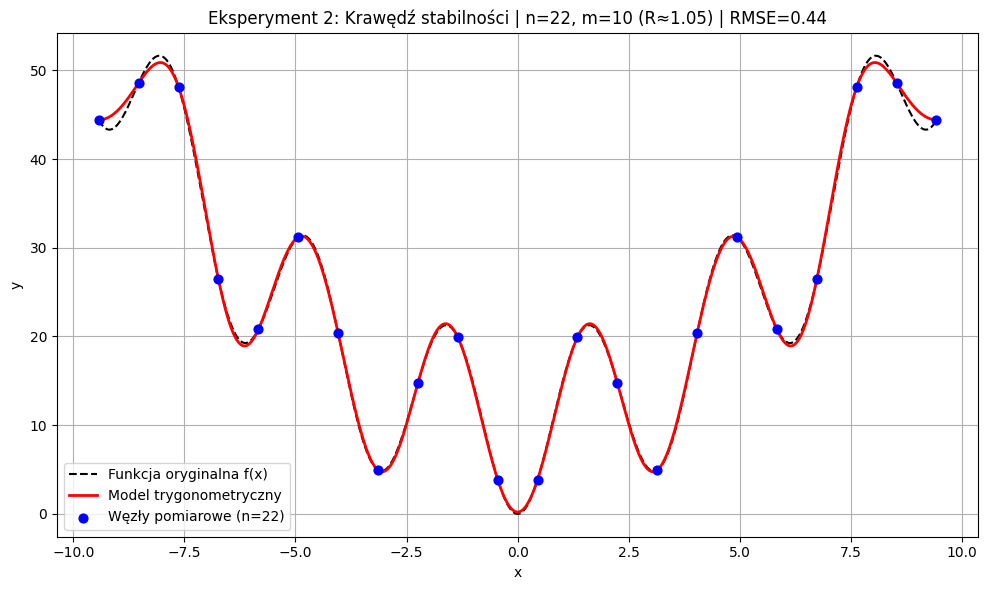

Zapisano wykres do: ./plots/trigonometric/exp2_n22_m10.png


In [8]:
# ==========================================
# EKSPERYMENT 2: Na krawędzi stabilności (R ≈ 1)
# ==========================================

n2 = 22
m2 = 10
# Liczba funkcji bazowych = 2*10 + 1 = 21
# R = 22 / 21 ≈ 1.05

x_nodes2 = np.linspace(a, b, n2)
y_nodes2 = f(x_nodes2)
basis2 = get_trig_basis(m2)

plt.figure(figsize=(10, 6))
plt.plot(x_dense, y_true_dense, 'k--', label='Funkcja oryginalna f(x)')

try:
    coeffs2 = solve_approximation(x_nodes2, y_nodes2, basis2)
    y_approx2 = evaluate_model(x_dense, coeffs2, basis2)
    rmse2 = np.sqrt(calculate_mse(y_true_dense, y_approx2))
    
    plt.plot(x_dense, y_approx2, 'r-', linewidth=2, label='Model trygonometryczny')
    title2 = f'Eksperyment 2: Krawędź stabilności | n={n2}, m={m2} (R≈1.05) | RMSE={rmse2:.2f}'
    
except np.linalg.LinAlgError:
    title2 = f'Eksperyment 2: Krawędź stabilności | n={n2}, m={m2} (R≈1.05) | BŁĄD OSOBLIWOŚCI'
    print("Ostrzeżenie: Przechwycono LinAlgError.")

plt.scatter(x_nodes2, y_nodes2, color='blue', s=40, zorder=5, label=f'Węzły pomiarowe (n={n2})')

plt.title(title2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

os.makedirs("./plots/trigonometric", exist_ok=True)
path2 = "./plots/trigonometric/exp2_n22_m10.png"

plt.tight_layout()
plt.savefig(path2, dpi=300)
plt.show()

print(f"Zapisano wykres do: {path2}")

### Eksperyment 3: Polowanie na "Złotą Harmoniczną" (przy stałym nadmiarze danych $R \approx 5$)

Wiemy już, że baza trygonometryczna potrafi idealnie zrekonstruować naszą funkcję, ponieważ wewnątrz przedziału $L = 6\pi$ potrafi wygenerować częstotliwość $\cos(2x)$. Wzór na harmoniczne to $\cos(k \frac{2\pi}{L} x) = \cos(k \frac{x}{3})$. Aby otrzymać $\cos(2x)$, potrzebujemy harmonicznej $k = 6$. Zatem stopień wielomianu $m$ musi wynosić co najmniej $6$.

W tym eksperymencie utrzymujemy stały, bardzo bezpieczny stosunek informacji do parametrów ($R \approx 5$), aby wykluczyć problemy z uwarunkowaniem macierzy, a badamy sam wpływ stopnia bazy $m$.

**Testowane warianty:**
1. $m = 3$ (Niedouczenie) -> $n = 35$ ($R = 5$)
2. $m = 6$ (Złota harmoniczna) -> $n = 65$ ($R = 5$)
3. $m = 10$ (Nadmiar parametrów) -> $n = 105$ ($R = 5$)

Spodziewamy się, że dla $m=3$ wielomian zignoruje oscylacje, dla $m=6$ idealnie ułoży się na funkcji, a dla $m=10$ wynik będzie identyczny jak dla $m=6$ (współczynniki dla wyższych harmonicznych zostaną wyzerowane).

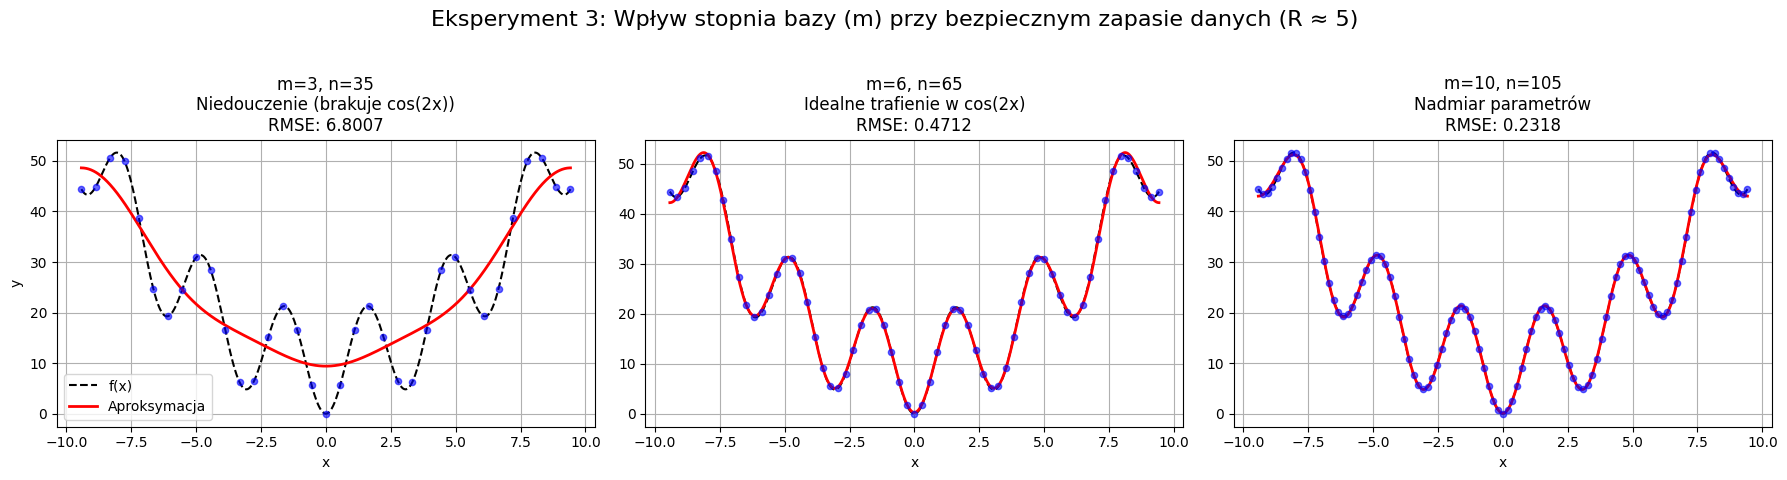

Zapisano wykres do: ./plots/trigonometric/exp3_zestawienie.png


In [9]:
# ==========================================
# EKSPERYMENT 3: Polowanie na Złotą Harmoniczną (R ≈ 5)
# ==========================================

# Parametry (m, n) tak, aby R wynosiło ok. 5
cases = [
    (3, 35, "Niedouczenie (brakuje cos(2x))"),
    (6, 65, "Idealne trafienie w cos(2x)"),
    (10, 105, "Nadmiar parametrów")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Eksperyment 3: Wpływ stopnia bazy (m) przy bezpiecznym zapasie danych (R ≈ 5)', fontsize=16)

for i, (m_val, n_val, desc) in enumerate(cases):
    ax = axes[i]
    
    x_nodes_exp3 = np.linspace(a, b, n_val)
    y_nodes_exp3 = f(x_nodes_exp3)
    basis_exp3 = get_trig_basis(m_val)
    
    coeffs_exp3 = solve_approximation(x_nodes_exp3, y_nodes_exp3, basis_exp3)
    y_approx_exp3 = evaluate_model(x_dense, coeffs_exp3, basis_exp3)
    rmse_exp3 = np.sqrt(calculate_mse(y_true_dense, y_approx_exp3))
    
    ax.plot(x_dense, y_true_dense, 'k--', label='f(x)')
    ax.plot(x_dense, y_approx_exp3, 'r-', linewidth=2, label='Aproksymacja')
    ax.scatter(x_nodes_exp3, y_nodes_exp3, color='blue', s=20, alpha=0.6, zorder=5)
    
    ax.set_title(f'm={m_val}, n={n_val}\n{desc}\nRMSE: {rmse_exp3:.4f}')
    ax.set_xlabel('x')
    ax.grid(True)
    if i == 0:
        ax.set_ylabel('y')
        ax.legend()

os.makedirs("./plots/trigonometric", exist_ok=True)
path3 = "./plots/trigonometric/exp3_zestawienie.png"

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(path3, dpi=300)
plt.show()

print(f"Zapisano wykres do: {path3}")